# RNN Training + Optuna + ONNX Export for MetaTrader 5

**Что делает ноутбук:**
1. Загружает CSV (data_BUY/SELL) из Google Drive
2. Optuna подбирает 7 гиперпараметров GRU + порог уверенности
3. Бэктест: WinRate, MaxDD, Profit Factor, Z-Score
4. Score: **PF × WR × (1−DD) × √(trades / (months×3))**
5. Экспортирует лучшие модели в ONNX + RNN_Scaler.mqh

**Структура Drive:**
```
Мой Диск / othercomputers/Ноутбук/RNN /
  data/          ← кинуть CSV сюда
  output/        ← результат
```

## Подключение Google Drive и базовые импорты

## 0. Проверка и установка зависимостей

Запускайте эту ячейку первой после каждого нового или перезапущенного Colab runtime. Она проверит окружение, установит отсутствующие пакеты и выведет версии.

In [13]:
# @title 0. Check / Install dependencies
import importlib.util
import subprocess
import sys

required = {
    'optuna': 'optuna',
    'onnx': 'onnx',
    'onnxruntime': 'onnxruntime',
    'onnxscript': 'onnxscript',
}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print('Устанавливаю отсутствующие пакеты:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('Все необходимые пакеты уже установлены.')

import onnx
import onnxruntime
import onnxscript
import optuna

print(f'onnx:       {onnx.__version__}')
print(f'onnxruntime: {onnxruntime.__version__}')
print(f'onnxscript:  {getattr(onnxscript, "__version__", "installed")}')
print(f'optuna:      {optuna.__version__}')
print('Зависимости готовы. Можно запускать ячейку 1 Setup.')


Устанавливаю отсутствующие пакеты: onnxscript
onnx:       1.22.0
onnxruntime: 1.29.0
onnxscript:  0.7.1
optuna:      4.9.0
Зависимости готовы. Можно запускать ячейку 1 Setup.


In [14]:
# @title 1. Mount Drive + install dependencies
import os, sys, glob, math, warnings, io, json
from pathlib import Path

# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Install missing packages ---
!pip install optuna onnx onnxruntime -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import onnx

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null || echo 'No GPU'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Tesla T4, 15360 MiB


## 2. Configuration

In [15]:
# @title 2. Paths & Constants

# --- Google Drive paths ---
DRIVE_BASE   = '/content/drive/MyDrive/RNN'
DATA_DIR     = os.path.join(DRIVE_BASE, 'data')
OUTPUT_DIR   = os.path.join(DRIVE_BASE, 'output')

# --- Trading parameters (MATCH PrepareData.mq5!) ---
SL_PIPS      = 15.0
TP_PIPS      = 20.0
HOLD_BARS    = 20
INITIAL_CAPITAL = 700.0

# --- Training constants ---
N_FEATURES   = 16       # признаков на бар (совпадает с MQL)
N_CLASSES    = 2        # DEAL / UNDEAL
BATCH_SIZE   = 64

# --- Optuna ---
N_TRIALS     = 50       # число попыток
TRAIN_EPOCHS = 40       # эпох на trial (сокращённый режим)
FINAL_EPOCHS = 70       # эпох для финала

# --- Trades baseline: N months in test x 3 trades/month ---
MIN_TRADES_PER_MONTH = 3

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Data:   {DATA_DIR}')
print(f'Output: {OUTPUT_DIR}')


Data:   /content/drive/MyDrive/RNN/data
Output: /content/drive/MyDrive/RNN/output


## 3. Data Loading

In [16]:
# @title 3. Adaptive normalization + CSV loader

def adaptive_normalize(X, eps=1e-6):
    """Adaptive normalization (ddof=0, matches NN_ApplyRollingNorm in MQL)."""
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, ddof=0, keepdims=True)
    std  = np.maximum(std, eps)
    return (X - mean) / std


def load_and_split_csv(filepath, seq_len, norm_window, eps=1e-6):
    """
    Load CSV, adaptive normalize, split 80/20 chronologically.
    Returns: train_loader, test_loader, df_test, seq_len, n_features, num_classes, n_months
    """
    df = pd.read_csv(filepath)
    has_datetime = 'datetime' in df.columns
    if has_datetime:
        df['datetime'] = pd.to_datetime(df['datetime'], format='%Y.%m.%d %H:%M')
        df = df.sort_values('datetime').reset_index(drop=True)

    feature_cols = [c for c in df.columns if c.startswith('lag')]
    if 'label' not in df.columns:
        raise KeyError(f"Column 'label' not found in {filepath}")

    n_bars = len(feature_cols) // N_FEATURES
    if n_bars * N_FEATURES != len(feature_cols):
        raise ValueError(f"Feature cols ({len(feature_cols)}) not divisible by N_FEATURES ({N_FEATURES})")
    if seq_len > n_bars:
        raise ValueError(f"seq_len ({seq_len}) > bars per row ({n_bars}). Reduce seq_len.")

    # Rolling windows for normalization
    if norm_window % n_bars != 0:
        raise ValueError(f"norm_window ({norm_window}) must be divisible by n_bars ({n_bars})")
    rows_per_window = norm_window // n_bars
    skip = rows_per_window
    if len(df) <= skip:
        raise ValueError(f"Need > {skip} rows, got {len(df)}")

    x_raw = df[feature_cols].values.astype(np.float64)
    x_raw = x_raw.reshape(-1, n_bars, N_FEATURES)

    chunks = np.lib.stride_tricks.sliding_window_view(x_raw, rows_per_window, axis=0)
    chunks = chunks[:, ::-1]
    X_raw = chunks.reshape(chunks.shape[0], -1, N_FEATURES)

    X_raw = X_raw[skip - rows_per_window + 1:]
    y = df['label'].values[skip:].astype(int)
    results = df['result'].values[skip:].astype(np.float64) if 'result' in df.columns else np.zeros(len(y))

    # Adaptive normalize
    X = adaptive_normalize(X_raw, eps)
    X = X[:, :seq_len, :]

    # Split chronologically 80/20
    n = X.shape[0]
    n_train = int(n * 0.8)

    X_train, X_test = X[:n_train], X[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]
    results_test = results[n_train:]

    # Number of months in test set (for trades baseline)
    n_months = 1
    if has_datetime and n - n_train > 0:
        dt_test = df['datetime'].iloc[n_train + skip:]
        if len(dt_test) > 0:
            n_months = max(1, math.ceil((dt_test.iloc[-1] - dt_test.iloc[0]).days / 30.44))

    # One-hot
    num_classes = len(np.unique(y))
    y_train_oh = np.eye(num_classes)[y_train]
    y_test_oh  = np.eye(num_classes)[y_test]

    # DataFrame slice for backtest
    df_test = df.iloc[n_train + skip:].reset_index(drop=True).copy()
    df_test['_result'] = results_test

    print(f"  {os.path.basename(filepath)}: {len(df)} rows, train={n_train}, test={n - n_train}")
    print(f"    n_bars={n_bars}, norm_window={norm_window}, seq_len={seq_len}, test_months={n_months}")
    print(f"    Classes: {dict(zip(*np.unique(y, return_counts=True)))}")

    # Datasets
    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train_oh))
    test_ds  = TensorDataset(torch.FloatTensor(X_test),  torch.FloatTensor(y_test_oh))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, test_loader, df_test, seq_len, N_FEATURES, num_classes, n_months


# --- Find CSV files (search in RNN/data AND RNN itself) ---
def find_csvs(pattern):
    found = []
    for d in (DATA_DIR, DRIVE_BASE):
        if os.path.isdir(d):
            found += sorted(glob.glob(os.path.join(d, pattern)))
    # dedupe preserving order
    seen = set()
    out = []
    for f in found:
        if f not in seen:
            seen.add(f)
            out.append(f)
    return out

buy_csvs  = find_csvs('data_BUY_*.csv')
sell_csvs = find_csvs('data_SELL_*.csv')

print(f'Search dirs:\n  {DATA_DIR}\n  {DRIVE_BASE}')
print(f'BUY:  {[os.path.basename(f) for f in buy_csvs]}')
print(f'SELL: {[os.path.basename(f) for f in sell_csvs]}')

if not buy_csvs or not sell_csvs:
    print(f'\nERROR: data_BUY_*.csv / data_SELL_*.csv not found.\n')
    print('What is in the folders:')
    for d in (DRIVE_BASE, DATA_DIR):
        if os.path.isdir(d):
            print(f'  {d}:')
            for f in sorted(os.listdir(d)):
                print(f'    {f}')
    raise FileNotFoundError('CSV missing')


Search dirs:
  /content/drive/MyDrive/RNN/data
  /content/drive/MyDrive/RNN
BUY:  ['data_BUY_20250102_20251230.csv']
SELL: ['data_SELL_20250102_20251230.csv']


## 4. GRU Model

In [17]:
# @title 4. GRU Classifier

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)


## 5. Backtest Engine

In [18]:
# @title 5. Backtest: simulate trades, compute 4 metrics + score

def backtest(model, test_loader, df_test, threshold, n_months, device, initial_capital=700.0):
    """
    Simulate trading chronologically on test set.
    Returns dict: win_rate, max_dd, profit_factor, z_score, n_trades, score, equity, trades.
    Score = PF * WR * (1-DD) * sqrt(trades / baseline)
    baseline = n_months * MIN_TRADES_PER_MONTH
    """
    model.eval()
    all_probs = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            y_pred = model(X_batch.to(device))
            probs = torch.softmax(y_pred, dim=1)[:, 1]  # class DEAL / profitable
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)

    # Simulate trades
    trades = []
    for i, prob in enumerate(all_probs):
        if prob > threshold and i < len(df_test):
            r = df_test.iloc[i]['_result']
            trades.append(float(r))

    n_trades = len(trades)
    if n_trades == 0:
        return {'win_rate': 0.0, 'max_dd': 1.0, 'profit_factor': 0.0,
                'z_score': 0.0, 'n_trades': 0, 'total_return': 0.0,
                'avg_trade': 0.0, 'score': -999.0, 'equity': [], 'trades': []}

    trades = np.array(trades)
    n_wins = int(np.sum(trades > 0))
    win_rate = n_wins / n_trades

    # Equity curve
    equity = initial_capital + np.cumsum(trades)
    equity_full = np.insert(equity, 0, initial_capital)
    peak = np.maximum.accumulate(equity_full)
    dd = (peak - equity_full) / np.maximum(peak, 1e-9)
    max_dd = float(np.max(dd))

    # Profit Factor
    gross_profit  = np.sum(trades[trades > 0])
    gross_loss    = abs(np.sum(trades[trades < 0]))
    profit_factor = float(gross_profit / gross_loss) if gross_loss > 0 else (float('inf') if gross_profit > 0 else 0.0)

    total_return = float(np.sum(trades))
    avg_trade    = total_return / n_trades

    # Z-Score: statistical significance
    if n_trades > 1 and 0 < win_rate < 1:
        z_score = float((win_rate - 0.5) * math.sqrt(n_trades) / math.sqrt(win_rate * (1 - win_rate)))
    else:
        z_score = 0.0

    # SCORE: PF * WR * (1-DD) * sqrt(trades / baseline)
    baseline = max(1, n_months * MIN_TRADES_PER_MONTH)
    pf_clip = min(profit_factor, 10.0)  # cap extreme PF
    score = pf_clip * win_rate * (1.0 - max_dd) * math.sqrt(n_trades / baseline)

    return {
        'win_rate':      win_rate,
        'max_dd':        max_dd,
        'profit_factor': profit_factor,
        'z_score':       z_score,
        'n_trades':      n_trades,
        'total_return':  total_return,
        'avg_trade':     avg_trade,
        'score':         score,
        'equity':        equity.tolist(),
        'trades':        trades.tolist(),
    }


def plot_backtest(metrics, title, save_path=None):
    if not metrics.get('equity'):
        print('  No trades to plot.')
        return
    equity = np.array(metrics['equity'])
    equity_full = np.insert(equity, 0, INITIAL_CAPITAL)
    peak = np.maximum.accumulate(equity_full)
    dd = (peak - equity_full) / np.maximum(peak, 1e-9)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ax1.plot(equity_full, 'b-', linewidth=1.0, label='Equity')
    ax1.plot(peak, 'g--', linewidth=0.8, alpha=0.7, label='Peak')
    ax1.fill_between(range(len(equity_full)), equity_full, peak, alpha=0.15, color='red')
    ax1.axhline(y=INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5)
    ax1.set_ylabel('Equity')
    ax1.set_title(title)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax2.fill_between(range(len(dd)), dd * 100, 0, alpha=0.3, color='red')
    ax2.plot(dd * 100, 'r-', linewidth=0.8)
    ax2.set_ylabel('Drawdown %')
    ax2.set_xlabel('Trade #')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Chart: {save_path}')
    plt.show()


## 6. Training

In [19]:
# @title 6. Train one model

def train_one_model(model, train_loader, epochs, lr, device, verbose=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.1)
    best_acc = 0.0
    best_state = None

    it = tqdm(range(epochs), desc='Train', leave=False) if verbose else range(epochs)
    for epoch in it:
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch.argmax(dim=1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
            correct   += (y_pred.argmax(dim=1) == y_batch.argmax(dim=1)).sum().item()
            total     += X_batch.size(0)
        train_loss = total_loss / total
        train_acc  = correct / total
        scheduler.step()
        if train_acc > best_acc:
            best_acc = train_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if verbose and hasattr(it, 'set_postfix'):
            it.set_postfix({'loss': f'{train_loss:.4f}', 'acc': f'{train_acc:.4f}'})
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_acc, train_loss


## 7. Optuna Optimization

In [20]:
# @title 7. Optuna: optimize 7 hyperparams (resumable)
# Study сохраняется на Drive (output/optuna_*/study.db).
# Если Colab упал — просто перезапусти эту ячейку: Optuna продолжит
# с последнего завершённого trial (уже завершённые не повторяются).

def load_or_create_study(mode_name):
    study_name = f'rnn_{mode_name}'
    optuna_dir = os.path.join(OUTPUT_DIR, f'optuna_{mode_name}')
    os.makedirs(optuna_dir, exist_ok=True)
    storage_path = os.path.join(optuna_dir, 'study.db')
    storage = f'sqlite:///{storage_path}'

    if os.path.exists(storage_path):
        print(f'  Найден сохранённый study: {storage_path}')
        study = optuna.load_study(study_name=study_name, storage=storage)
        done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
        print(f'  Уже завершено trials: {done}')
        return study

    print(f'  Новый study: {storage_path}')
    return optuna.create_study(
        study_name=study_name,
        storage=storage,
        load_if_exists=True,
        direction='maximize',
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5, interval_steps=1),
    )


def run_optuna(csv_path, mode_name, n_trials=50):
    # Run or resume Optuna study for one mode (BUY/SELL)
    study = load_or_create_study(mode_name)

    done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    remaining = n_trials - done
    if remaining <= 0:
        print(f'  {mode_name}: уже {done} trials из {n_trials}. Нечего запускать.')
        return study.best_params, study

    print(f'  {mode_name}: {done}/{n_trials} trials сделано, запускаю ещё {remaining}...')

    def objective(trial):
        seq_len      = trial.suggest_int('seq_len', 3, 10, step=2)          # 3,5,7,9
        norm_window  = trial.suggest_int('norm_window', 50, 200, step=50)   # 50,100,150,200
        hidden_size  = trial.suggest_int('hidden_size', 32, 128, step=16)
        num_layers   = trial.suggest_int('num_layers', 1, 3)
        dropout      = trial.suggest_float('dropout', 0.1, 0.4, step=0.05)
        lr           = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
        conf_thresh  = trial.suggest_float('conf_threshold', 0.5, 0.95, step=0.1)  # 0.5..0.9

        try:
            train_loader, test_loader, df_test, seq_len_actual, n_features, num_classes, n_months = \
                load_and_split_csv(csv_path, seq_len=seq_len, norm_window=norm_window)
        except Exception as e:
            print(f'  Trial {trial.number} FAILED: {e}')
            return -999.0

        model = GRUClassifier(n_features, hidden_size, num_layers, num_classes, dropout)
        model, train_acc, _ = train_one_model(model, train_loader, TRAIN_EPOCHS, lr, DEVICE, verbose=False)
        metrics = backtest(model, test_loader, df_test, conf_thresh, n_months, DEVICE, INITIAL_CAPITAL)

        trial.report(metrics['score'], step=TRAIN_EPOCHS)
        if trial.should_prune():
            raise optuna.TrialPruned()

        print(f'  T{trial.number:3d} | s={seq_len} nw={norm_window} h={hidden_size} L={num_layers} '
              f'dr={dropout:.2f} lr={lr:.5f} th={conf_thresh:.2f} | '
              f"WR={metrics['win_rate']:.3f} DD={metrics['max_dd']:.3f} "
              f"PF={metrics['profit_factor']:.2f} Z={metrics['z_score']:.2f} "
              f"N={metrics['n_trades']:4d} score={metrics['score']:.4f}")

        return metrics['score']

    print(f"\n{'='*70}")
    print(f'OPTUNA: {mode_name} | всего {n_trials} trials | score = PF*WR*(1-DD)*sqrt(N/baseline)')
    print(f"{'='*70}")
    study.optimize(objective, n_trials=remaining, show_progress_bar=True)

    print(f'\nBest {mode_name}: score={study.best_value:.4f}')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')
    return study.best_params, study


# --- BUY ---
buy_params, buy_study = run_optuna(buy_csvs[0], 'BUY', N_TRIALS)

# --- SELL ---
sell_params, sell_study = run_optuna(sell_csvs[0], 'SELL', N_TRIALS)


  Найден сохранённый study: /content/drive/MyDrive/RNN/output/optuna_BUY/study.db
  Уже завершено trials: 44
  BUY: 44/50 trials сделано, запускаю ещё 6...

OPTUNA: BUY | всего 50 trials | score = PF*WR*(1-DD)*sqrt(N/baseline)


  0%|          | 0/6 [00:00<?, ?it/s]

  data_BUY_20250102_20251230.csv: 2851 rows, train=2272, test=569
    n_bars=10, norm_window=100, seq_len=5, test_months=3
    Classes: {np.int64(0): np.int64(1609), np.int64(1): np.int64(1232)}
  T 73 | s=5 nw=100 h=48 L=2 dr=0.40 lr=0.00407 th=0.60 | WR=0.494 DD=0.314 PF=1.23 Z=-0.19 N= 239 score=2.1378
[I 2026-08-20 12:44:51,286] Trial 73 finished with value: 2.137840547695518 and parameters: {'seq_len': 5, 'norm_window': 100, 'hidden_size': 48, 'num_layers': 2, 'dropout': 0.4, 'lr': 0.004069805855536725, 'conf_threshold': 0.6}. Best is trial 73 with value: 2.137840547695518.
  data_BUY_20250102_20251230.csv: 2851 rows, train=2272, test=569
    n_bars=10, norm_window=100, seq_len=5, test_months=3
    Classes: {np.int64(0): np.int64(1609), np.int64(1): np.int64(1232)}
  T 74 | s=5 nw=100 h=48 L=2 dr=0.40 lr=0.00492 th=0.60 | WR=0.476 DD=0.470 PF=1.13 Z=-0.77 N= 246 score=1.4934
[I 2026-08-20 12:44:56,433] Trial 74 finished with value: 1.493361940504941 and parameters: {'seq_len': 5, 

  0%|          | 0/7 [00:00<?, ?it/s]

  data_SELL_20250102_20251230.csv: 3032 rows, train=2413, test=604
    n_bars=10, norm_window=150, seq_len=9, test_months=3
    Classes: {np.int64(0): np.int64(1706), np.int64(1): np.int64(1311)}
[I 2026-08-20 12:45:23,014] Trial 79 pruned. 
  data_SELL_20250102_20251230.csv: 3032 rows, train=2413, test=604
    n_bars=10, norm_window=150, seq_len=9, test_months=3
    Classes: {np.int64(0): np.int64(1706), np.int64(1): np.int64(1311)}
  T 80 | s=9 nw=150 h=64 L=2 dr=0.25 lr=0.00141 th=0.70 | WR=1.000 DD=0.000 PF=inf Z=0.00 N=   2 score=4.7140
[I 2026-08-20 12:45:28,095] Trial 80 finished with value: 4.714045207910317 and parameters: {'seq_len': 9, 'norm_window': 150, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.25, 'lr': 0.00141001702053987, 'conf_threshold': 0.7}. Best is trial 45 with value: 4.714045207910317.
  data_SELL_20250102_20251230.csv: 3032 rows, train=2413, test=604
    n_bars=10, norm_window=150, seq_len=9, test_months=3
    Classes: {np.int64(0): np.int64(1706), np.int

## 8. Final Training + Backtest


FINAL: BUY | s=5 nw=100 h=48 L=2 dr=0.40 lr=0.004070 th=0.60
  data_BUY_20250102_20251230.csv: 2851 rows, train=2272, test=569
    n_bars=10, norm_window=100, seq_len=5, test_months=3
    Classes: {np.int64(0): np.int64(1609), np.int64(1): np.int64(1232)}


Train:   0%|          | 0/70 [00:00<?, ?it/s]


  Train Acc: 0.6536, Loss: 0.6161

  BACKTEST BUY (test=3mo, baseline=9 trades):
  ──────────────────────────────────────────────────
  Trades:        254
  Win Rate:      0.4803 (48.0%)
  Max Drawdown:  0.8338 (83.4%)
  Profit Factor: 1.10
  Z-Score:       -0.63
  Total Return:  394.68
  Avg Trade:     1.5539
  Score:         0.4647
  ──────────────────────────────────────────────────

FINAL: SELL | s=9 nw=150 h=112 L=2 dr=0.20 lr=0.000628 th=0.70
  data_SELL_20250102_20251230.csv: 3032 rows, train=2413, test=604
    n_bars=10, norm_window=150, seq_len=9, test_months=3
    Classes: {np.int64(0): np.int64(1706), np.int64(1): np.int64(1311)}


Train:   0%|          | 0/70 [00:00<?, ?it/s]


  Train Acc: 0.5935, Loss: 0.6694

  BACKTEST SELL (test=3mo, baseline=9 trades):
  ──────────────────────────────────────────────────
  Trades:        8
  Win Rate:      0.5000 (50.0%)
  Max Drawdown:  0.1140 (11.4%)
  Profit Factor: 1.17
  Z-Score:       0.00
  Total Return:  21.60
  Avg Trade:     2.7000
  Score:         0.4878
  ──────────────────────────────────────────────────
  Chart: /content/drive/MyDrive/RNN/output/buy_backtest.png


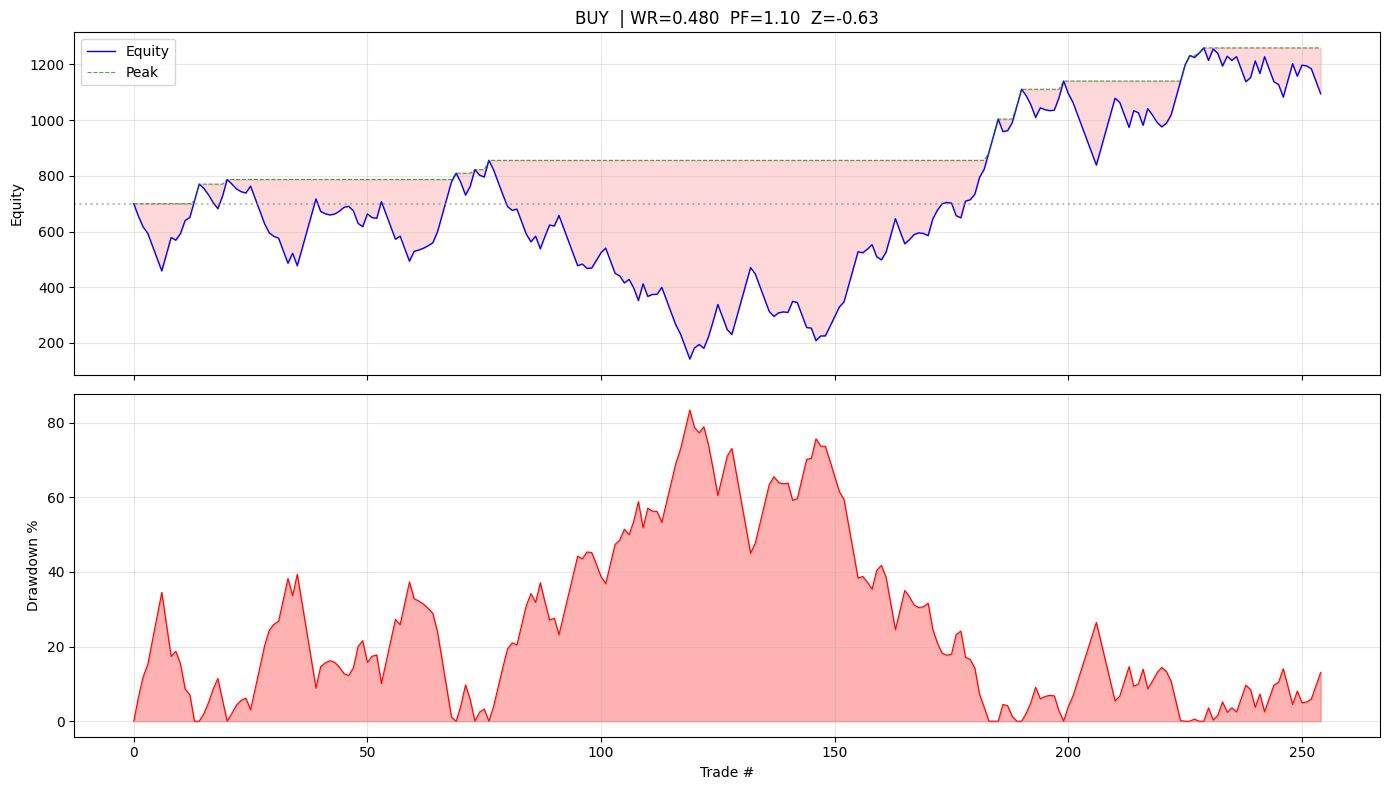

  Chart: /content/drive/MyDrive/RNN/output/sell_backtest.png


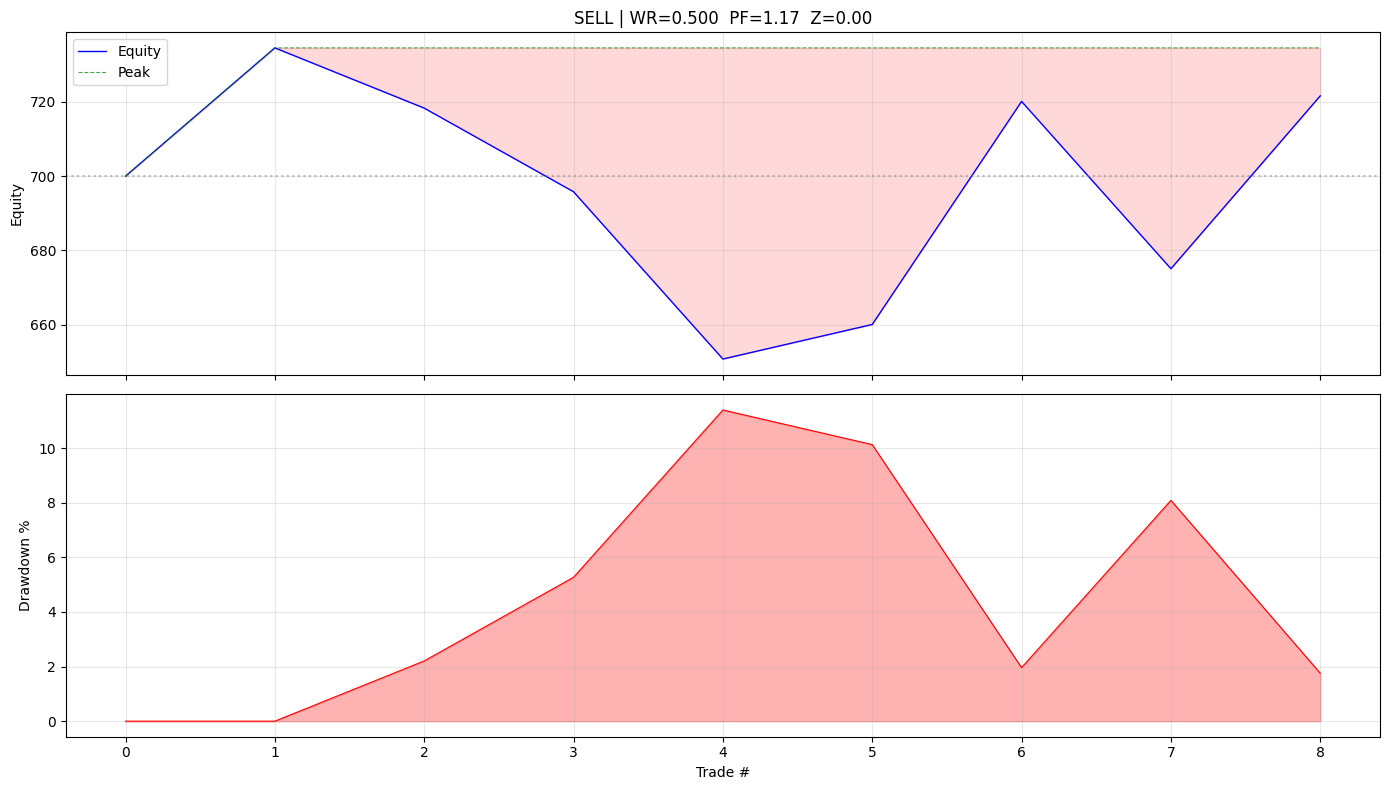

In [21]:
# @title 8. Train best models + backtest

def final_train_and_evaluate(csv_path, params, mode_name):
    seq_len      = params['seq_len']
    norm_window  = params['norm_window']
    hidden_size  = params['hidden_size']
    num_layers   = params['num_layers']
    dropout      = params['dropout']
    lr           = params['lr']
    conf_thresh  = params['conf_threshold']

    print(f"\n{'='*70}")
    print(f"FINAL: {mode_name} | s={seq_len} nw={norm_window} h={hidden_size} L={num_layers} dr={dropout:.2f} "
          f"lr={lr:.6f} th={conf_thresh:.2f}")
    print(f"{'='*70}")

    train_loader, test_loader, df_test, seq_len_actual, n_features, num_classes, n_months = \
        load_and_split_csv(csv_path, seq_len=seq_len, norm_window=norm_window)

    model = GRUClassifier(n_features, hidden_size, num_layers, num_classes, dropout)
    model, train_acc, train_loss = train_one_model(model, train_loader, FINAL_EPOCHS, lr, DEVICE, verbose=True)
    print(f"\n  Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f}")

    metrics = backtest(model, test_loader, df_test, conf_thresh, n_months, DEVICE, INITIAL_CAPITAL)
    baseline = max(1, n_months * MIN_TRADES_PER_MONTH)

    print(f"\n  BACKTEST {mode_name} (test={n_months}mo, baseline={baseline} trades):")
    print(f"  {'─'*50}")
    print(f"  Trades:        {metrics['n_trades']}")
    print(f"  Win Rate:      {metrics['win_rate']:.4f} ({metrics['win_rate']*100:.1f}%)")
    print(f"  Max Drawdown:  {metrics['max_dd']:.4f} ({metrics['max_dd']*100:.1f}%)")
    print(f"  Profit Factor: {metrics['profit_factor']:.2f}")
    print(f"  Z-Score:       {metrics['z_score']:.2f}" + (' *' if abs(metrics['z_score']) > 2.0 else ''))
    print(f"  Total Return:  {metrics['total_return']:.2f}")
    print(f"  Avg Trade:     {metrics['avg_trade']:.4f}")
    print(f"  Score:         {metrics['score']:.4f}")
    print(f"  {'─'*50}")

    return model, metrics, seq_len, n_features, norm_window


buy_model,  buy_metrics,  buy_seq_len,  buy_nf, buy_nw = final_train_and_evaluate(buy_csvs[0],  buy_params,  'BUY')
sell_model, sell_metrics, sell_seq_len, sell_nf, sell_nw = final_train_and_evaluate(sell_csvs[0], sell_params, 'SELL')

# --- Plot ---
plot_backtest(buy_metrics,  f'BUY  | WR={buy_metrics["win_rate"]:.3f}  PF={buy_metrics["profit_factor"]:.2f}  Z={buy_metrics["z_score"]:.2f}',
              os.path.join(OUTPUT_DIR, 'buy_backtest.png'))
plot_backtest(sell_metrics, f'SELL | WR={sell_metrics["win_rate"]:.3f}  PF={sell_metrics["profit_factor"]:.2f}  Z={sell_metrics["z_score"]:.2f}',
              os.path.join(OUTPUT_DIR, 'sell_backtest.png'))


## 9. ONNX Export + RNN_Scaler.mqh

In [22]:
# @title 9. Export ONNX + generate MQL config

def export_to_onnx(model, seq_len, n_features, out_path, name):
    """Export to self-contained ONNX (no .data files). Required for OnnxCreateFromBuffer."""
    model.eval()
    model.to('cpu')
    dummy = torch.randn(1, seq_len, n_features)
    tmp = out_path + '.tmp'
    old = sys.stdout
    sys.stdout = io.StringIO()
    try:
        torch.onnx.export(model, dummy, tmp,
                          input_names=['input'], output_names=['output'],
                          dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
                          opset_version=18)
    finally:
        sys.stdout = old
    m = onnx.load(tmp)
    raw_bytes = m.SerializeToString()
    if b'.onnx.data' in raw_bytes:
        raise RuntimeError(f'{name}: external .data reference!')
    with open(out_path, 'wb') as f:
        f.write(raw_bytes)
    for x in (tmp, tmp + '.data', out_path + '.data'):
        if os.path.exists(x): os.remove(x)
    kb = os.path.getsize(out_path) / 1024
    print(f'  {name}: {out_path} ({kb:.1f} KB)')


def generate_scaler_mqh(buy_seq_len, buy_norm_window, sell_seq_len, sell_norm_window, n_features, eps, out_path):
    lines = [
        '//+------------------------------------------------------------------+',
        '//|                                              RNN_Scaler.mqh      |',
        '//|   Адаптивная нормализация (Optuna).                            |',
        '//|   Сгенерировано: Colab.                                        |',
        '//+------------------------------------------------------------------+',
        '#ifndef RNN_SCALER_MQH',
        '#define RNN_SCALER_MQH',
        '',
        f'#define NN_BUY_NORM_WINDOW  {buy_norm_window}   // BUY normalization window',
        f'#define NN_BUY_SEQ_LEN      {buy_seq_len}       // BUY input window',
        f'#define NN_SELL_NORM_WINDOW {sell_norm_window}   // SELL normalization window',
        f'#define NN_SELL_SEQ_LEN     {sell_seq_len}       // SELL input window',
        f'#define NN_MAX_NORM_WINDOW  {max(buy_norm_window, sell_norm_window)}',
        f'#define NN_FEATURES      {n_features}    // признаков на бар',
        f'#define NN_NORM_STD_EPS  {eps:g}         // epsilon',
        '',
        '/* Direction-neutral aliases for existing data preparation tools. */',
        '#define NN_NORM_WINDOW NN_BUY_NORM_WINDOW',
        '#define NN_SEQ_LEN     NN_BUY_SEQ_LEN',
        '',
        '#endif // RNN_SCALER_MQH',
        '',
    ]
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))
    print(f'  RNN_Scaler.mqh -> {out_path}')


# --- Both models share the feature count; their windows are independent. ---
if buy_nf != sell_nf:
    raise ValueError(f'BUY/SELL feature count differs: {buy_nf} vs {sell_nf}')
generate_scaler_mqh(buy_seq_len, buy_nw, sell_seq_len, sell_nw, buy_nf, 1e-6,
                     os.path.join(OUTPUT_DIR, 'RNN_Scaler.mqh'))

# --- Export ONNX ---
onnx_dir = os.path.join(OUTPUT_DIR, 'onnx')
os.makedirs(onnx_dir, exist_ok=True)
export_to_onnx(buy_model,  buy_seq_len,  buy_nf, os.path.join(onnx_dir, 'buy_model.onnx'),  'buy')
export_to_onnx(sell_model, sell_seq_len, sell_nf, os.path.join(onnx_dir, 'sell_model.onnx'), 'sell')


  RNN_Scaler.mqh -> /content/drive/MyDrive/RNN/output/RNN_Scaler.mqh
  buy: /content/drive/MyDrive/RNN/output/onnx/buy_model.onnx (122.5 KB)
  sell: /content/drive/MyDrive/RNN/output/onnx/sell_model.onnx (511.6 KB)


## 10. Save All Artifacts

In [23]:
# @title 10. Save models + summary to Drive

# --- Save .pth ---
models_dir = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(models_dir, exist_ok=True)
torch.save(buy_model.state_dict(),  os.path.join(models_dir, 'model_buy_final.pth'))
torch.save(sell_model.state_dict(), os.path.join(models_dir, 'model_sell_final.pth'))
print(f'Models: {models_dir}/')

# --- Summary JSON ---
def safe(v):
    if isinstance(v, (np.floating,)): return float(v)
    if isinstance(v, (np.integer,)):  return int(v)
    if isinstance(v, np.ndarray):     return v.tolist()
    return v

summary = {
    'buy_metrics':  {k: safe(v) for k, v in buy_metrics.items() if k not in ('equity','trades')},
    'sell_metrics': {k: safe(v) for k, v in sell_metrics.items() if k not in ('equity','trades')},
    'buy_params':   {k: safe(v) for k, v in buy_params.items()},
    'sell_params':  {k: safe(v) for k, v in sell_params.items()},
    'sl_pips':  SL_PIPS,
    'tp_pips':  TP_PIPS,
}
with open(os.path.join(OUTPUT_DIR, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=safe)
print(f'Summary: {OUTPUT_DIR}/summary.json')

# --- Final report ---
print(f"\n{'='*70}")
print(f"DONE! Files in: {OUTPUT_DIR}/")
print(f"{'='*70}")
print(f"\nDownload to local MT5:\n")
print(f"  1. {onnx_dir}/buy_model.onnx  -> Common\\Files\\RNN\\buy_model.onnx")
print(f"  2. {onnx_dir}/sell_model.onnx -> Common\\Files\\RNN\\sell_model.onnx")
print(f"  3. {OUTPUT_DIR}/RNN_Scaler.mqh -> MQL5\\Experts\\RNN\\RNN_Scaler.mqh")
print(f"\nBUY:  WR={buy_metrics['win_rate']:.3f} DD={buy_metrics['max_dd']:.3f} PF={buy_metrics['profit_factor']:.2f} Z={buy_metrics['z_score']:.2f} N={buy_metrics['n_trades']}")
print(f"SELL: WR={sell_metrics['win_rate']:.3f} DD={sell_metrics['max_dd']:.3f} PF={sell_metrics['profit_factor']:.2f} Z={sell_metrics['z_score']:.2f} N={sell_metrics['n_trades']}")


Models: /content/drive/MyDrive/RNN/output/models/
Summary: /content/drive/MyDrive/RNN/output/summary.json

DONE! Files in: /content/drive/MyDrive/RNN/output/

Download to local MT5:

  1. /content/drive/MyDrive/RNN/output/onnx/buy_model.onnx  -> Common\Files\RNN\buy_model.onnx
  2. /content/drive/MyDrive/RNN/output/onnx/sell_model.onnx -> Common\Files\RNN\sell_model.onnx
  3. /content/drive/MyDrive/RNN/output/RNN_Scaler.mqh -> MQL5\Experts\RNN\RNN_Scaler.mqh

BUY:  WR=0.480 DD=0.834 PF=1.10 Z=-0.63 N=254
SELL: WR=0.500 DD=0.114 PF=1.17 Z=0.00 N=8
